# 07 — Latent Manipulation
**Dự án:** Latent Manipulation of Brain MRI using Volume-Preserving GANs

**Mục tiêu:** Dùng model tốt nhất từ file 03 và 06 để simulate aging:
- Lấy 1 ảnh não gốc
- Giữ nguyên giải phẫu
- Thay đổi tuổi trong latent space → sinh ra não ở các mốc tuổi khác nhau

**Output:**
```
latent_manipulation/
├── 2d_aging_simulation.png   ← kết quả GAN 2D
└── 3d_aging_simulation.png   ← kết quả GAN 3D (axial slice)
```

## Bước 1: Cấu hình

In [13]:
import os
import json

# ==== MODEL 2D ====
COMPARE_2D_JSON   = '/kaggle/input/datasets/minhbodoi/compare-2d/comparison_result.json'
MODEL_2D_NORM     = '/kaggle/input/datasets/minhbodoi/gan2d-normalized/best_model.pth'
MODEL_2D_UNNORM   = '/kaggle/input/datasets/minhbodoi/gan2d-unnormalized/best_model.pth'

# ==== MODEL 3D ====
COMPARE_3D_JSON   = '/kaggle/input/datasets/minhbodoi/compare-3d/comparison_result.json'
MODEL_3D_NORM     = '/kaggle/input/datasets/minhbodoi/gan3d-normalized/best_model.pth'
MODEL_3D_UNNORM   = '/kaggle/input/datasets/minhbodoi/gan3d-unnormalized/best_model.pth'

# ==== DATA ====
DATA_2D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/pre2dthatlan2/preprocessed_2d/normalized'
DATA_2D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/pre2dthatlan2/preprocessed_2d/unnormalized'
DATA_3D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/pre3dthatlan2/preprocessed_3d/normalized'
DATA_3D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/pre3dthatlan2/preprocessed_3d/unnormalized'
LABELS_2D_CSV      = '/kaggle/input/datasets/minhbodoi/pre2dthatlan2/preprocessed_2d/preprocessing_log.csv'
LABELS_3D_CSV      = '/kaggle/input/datasets/minhbodoi/pre3dthatlan2/preprocessed_3d/preprocessing_log.csv'

OUTPUT_DIR = '/kaggle/working/latent_manipulation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Mốc tuổi muốn simulate
TARGET_AGES = [20, 30, 40, 50, 60, 70, 80]
LATENT_DIM  = 256

# Đọc winner từ file so sánh
with open(COMPARE_2D_JSON) as f:
    winner_2d = json.load(f)['winner']
with open(COMPARE_3D_JSON) as f:
    winner_3d = json.load(f)['winner']

MODEL_2D_PATH = MODEL_2D_NORM   if winner_2d == 'normalized' else MODEL_2D_UNNORM
MODEL_3D_PATH = MODEL_3D_NORM   if winner_3d == 'normalized' else MODEL_3D_UNNORM
DATA_2D_DIR   = DATA_2D_NORM_DIR if winner_2d == 'normalized' else DATA_2D_UNNORM_DIR
DATA_3D_DIR   = DATA_3D_NORM_DIR if winner_3d == 'normalized' else DATA_3D_UNNORM_DIR

print(f'Winner 2D: {winner_2d} → {MODEL_2D_PATH}')
print(f'Winner 3D: {winner_3d} → {MODEL_3D_PATH}')

Winner 2D: normalized → /kaggle/input/datasets/minhbodoi/gan2d-normalized/best_model.pth
Winner 3D: unnormalized → /kaggle/input/datasets/minhbodoi/gan3d-unnormalized/best_model.pth


## Bước 2: Import thư viện

In [14]:
!pip install nibabel -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from PIL import Image
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Bước 3: Định nghĩa kiến trúc model

In [15]:
class AgeEmbedding(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
    def forward(self, age):
        return self.net(age.unsqueeze(-1))


# ===== 2D =====
class UNetBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm2d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator2D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 512)
        self.e1 = UNetBlock2D(1,   64,  down=True, use_bn=False)
        self.e2 = UNetBlock2D(64,  128, down=True)
        self.e3 = UNetBlock2D(128, 256, down=True)
        self.e4 = UNetBlock2D(256, 512, down=True)
        self.e5 = UNetBlock2D(512, 512, down=True)
        self.e6 = UNetBlock2D(512, 512, down=True)
        self.e7 = UNetBlock2D(512, 512, down=True)
        self.e8 = UNetBlock2D(512, 512, down=True, use_bn=False)
        self.d1 = UNetBlock2D(512,  512, down=False, dropout=True)
        self.d2 = UNetBlock2D(1024, 512, down=False, dropout=True)
        self.d3 = UNetBlock2D(1024, 512, down=False, dropout=True)
        self.d4 = UNetBlock2D(1024, 512, down=False)
        self.d5 = UNetBlock2D(1024, 256, down=False)
        self.d6 = UNetBlock2D(512,  128, down=False)
        self.d7 = UNetBlock2D(256,  64,  down=False)
        self.out = nn.Sequential(nn.ConvTranspose2d(128, 1, 4, 2, 1), nn.Tanh())

    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        z = e8 + self.age_proj(self.age_embed(age)).view(-1, 512, 1, 1)
        d1=self.d1(z)
        d2=self.d2(torch.cat([d1,e7],dim=1))
        d3=self.d3(torch.cat([d2,e6],dim=1))
        d4=self.d4(torch.cat([d3,e5],dim=1))
        d5=self.d5(torch.cat([d4,e4],dim=1))
        d6=self.d6(torch.cat([d5,e3],dim=1))
        d7=self.d7(torch.cat([d6,e2],dim=1))
        return self.out(torch.cat([d7,e1],dim=1))


# ===== 3D =====
class UNetBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv3d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose3d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm3d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator3D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 256)
        self.e1 = UNetBlock3D(1,   32,  down=True, use_bn=False)
        self.e2 = UNetBlock3D(32,  64,  down=True)
        self.e3 = UNetBlock3D(64,  128, down=True)
        self.e4 = UNetBlock3D(128, 256, down=True, use_bn=False)
        self.d1 = UNetBlock3D(256, 128, down=False, dropout=True)
        self.d2 = UNetBlock3D(256, 64,  down=False)
        self.d3 = UNetBlock3D(128, 32,  down=False)
        self.out = nn.Sequential(nn.ConvTranspose3d(64, 1, 4, 2, 1), nn.Tanh())

    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        z = e4 + self.age_proj(self.age_embed(age)).view(-1, 256, 1, 1, 1)
        d1=self.d1(z)
        d2=self.d2(torch.cat([d1,e3],dim=1))
        d3=self.d3(torch.cat([d2,e2],dim=1))
        return self.out(torch.cat([d3,e1],dim=1))


print('Kiến trúc model định nghĩa xong!')

Kiến trúc model định nghĩa xong!


## Bước 4: Load model tốt nhất

In [16]:
# Load GAN 2D
ckpt_2d = torch.load(MODEL_2D_PATH, map_location=DEVICE)
G2D     = Generator2D(LATENT_DIM).to(DEVICE)
G2D.load_state_dict(ckpt_2d['G_state'])
G2D.eval()

# Load GAN 3D
ckpt_3d = torch.load(MODEL_3D_PATH, map_location=DEVICE)
G3D     = Generator3D(LATENT_DIM).to(DEVICE)
G3D.load_state_dict(ckpt_3d['G_state'])
G3D.eval()

print(f'GAN 2D loaded — best loss_G: {ckpt_2d["best_loss_G"]:.4f}')
print(f'GAN 3D loaded — best loss_G: {ckpt_3d["best_loss_G"]:.4f}')

GAN 2D loaded — best loss_G: 0.6927
GAN 3D loaded — best loss_G: 0.6973


## Bước 5: Latent Manipulation — GAN 2D

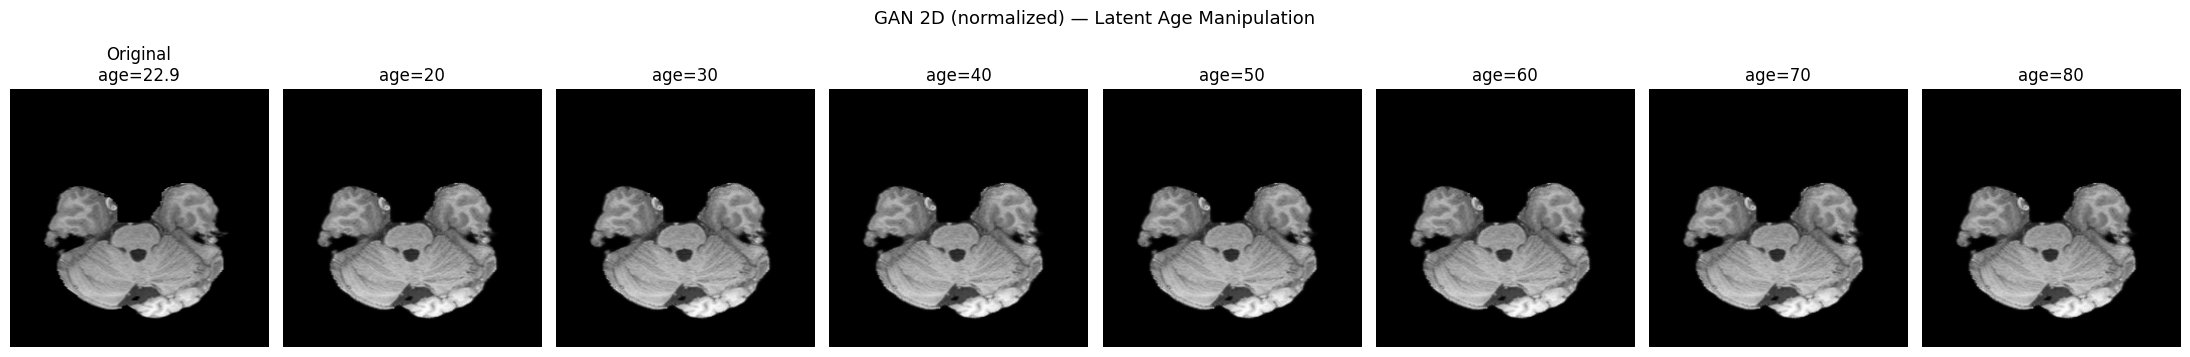

GAN 2D latent manipulation xong!


In [17]:
# Load 1 sample PNG
df_2d    = pd.read_csv(LABELS_2D_CSV)
png_path = os.path.join(DATA_2D_DIR, df_2d['png_file'].iloc[0])
age_orig = df_2d['age'].iloc[0]

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
sample_2d = transform(Image.open(png_path).convert('L')).unsqueeze(0).to(DEVICE)

def normalize_age_2d(age):
    return 2 * (age - ckpt_2d['age_min']) / (ckpt_2d['age_max'] - ckpt_2d['age_min']) - 1

# Simulate aging
fig, axes = plt.subplots(1, len(TARGET_AGES) + 1, figsize=(22, 4))
fig.suptitle(f'GAN 2D ({winner_2d}) — Latent Age Manipulation', fontsize=13)

orig_np = (sample_2d[0, 0].cpu().numpy() + 1) / 2
axes[0].imshow(orig_np, cmap='gray')
axes[0].set_title(f'Original\nage={age_orig:.1f}')
axes[0].axis('off')

with torch.no_grad():
    for i, target_age in enumerate(TARGET_AGES):
        age_t    = torch.tensor([normalize_age_2d(target_age)], dtype=torch.float32).to(DEVICE)
        fake_img = G2D(sample_2d, age_t)
        fake_np  = (fake_img[0, 0].cpu().numpy() + 1) / 2
        axes[i+1].imshow(fake_np, cmap='gray')
        axes[i+1].set_title(f'age={target_age}')
        axes[i+1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/2d_aging_simulation.png', dpi=120, bbox_inches='tight')
plt.show()
print('GAN 2D latent manipulation xong!')

## Bước 6: Latent Manipulation — GAN 3D

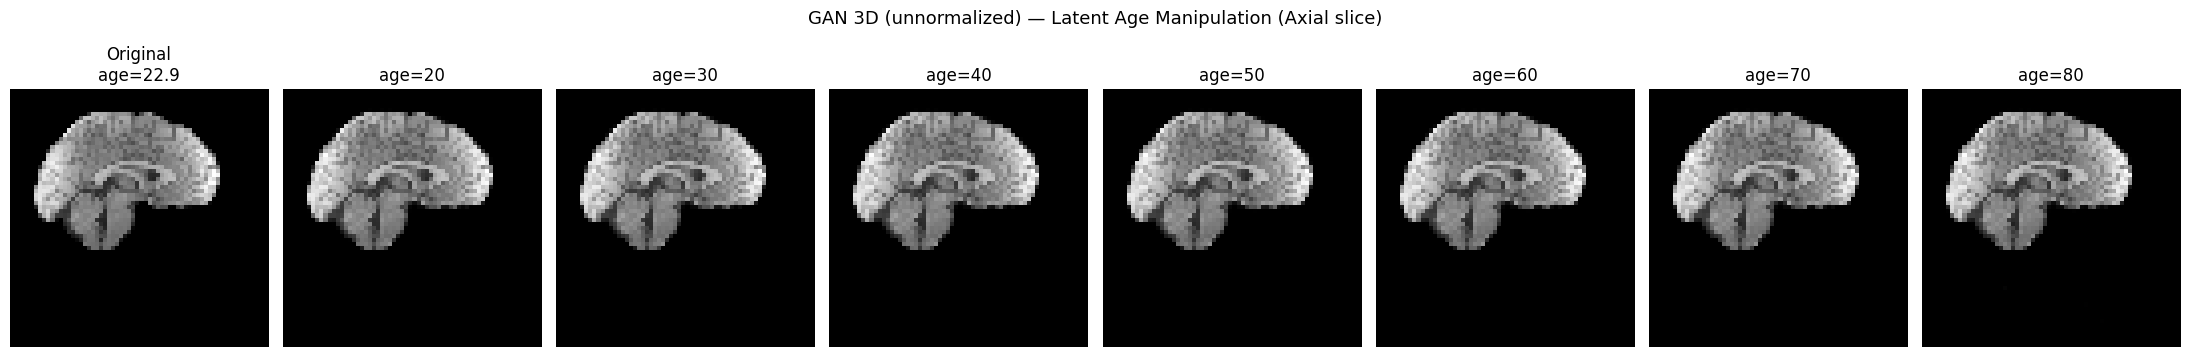

GAN 3D latent manipulation xong!


In [18]:
# Load 1 sample NIfTI
df_3d = pd.read_csv(LABELS_3D_CSV)
subject_id = df_3d['subject_id'].iloc[0]
age_orig_3d = df_3d['age'].iloc[0]
volume_size = ckpt_3d['volume_size']

def find_nii(data_dir, subject_id):
    for ext in ['.nii.gz', '.nii']:
        path = os.path.join(data_dir, f'{subject_id}{ext}')
        if os.path.exists(path):
            return path
    return None

nii_path = find_nii(DATA_3D_DIR, subject_id)
data     = nib.load(nii_path).get_fdata().astype(np.float32)
vol      = torch.tensor(data).unsqueeze(0).unsqueeze(0)
vol      = F.interpolate(vol, size=(volume_size,)*3, mode='trilinear', align_corners=False)
sample_3d = (vol.squeeze(0) * 2 - 1).unsqueeze(0).to(DEVICE)

def normalize_age_3d(age):
    return 2 * (age - ckpt_3d['age_min']) / (ckpt_3d['age_max'] - ckpt_3d['age_min']) - 1

# Simulate aging — hiển thị axial slice giữa
fig, axes = plt.subplots(1, len(TARGET_AGES) + 1, figsize=(22, 4))
fig.suptitle(f'GAN 3D ({winner_3d}) — Latent Age Manipulation (Axial slice)', fontsize=13)

orig_vol = (sample_3d[0, 0].cpu().numpy() + 1) / 2
axes[0].imshow(orig_vol[volume_size//2, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original\nage={age_orig_3d:.1f}')
axes[0].axis('off')

with torch.no_grad():
    for i, target_age in enumerate(TARGET_AGES):
        age_t    = torch.tensor([normalize_age_3d(target_age)], dtype=torch.float32).to(DEVICE)
        fake_vol = G3D(sample_3d, age_t)
        fake_np  = (fake_vol[0, 0].cpu().numpy() + 1) / 2
        axes[i+1].imshow(fake_np[volume_size//2, :, :].T, cmap='gray', origin='lower')
        axes[i+1].set_title(f'age={target_age}')
        axes[i+1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/3d_aging_simulation.png', dpi=120, bbox_inches='tight')
plt.show()
print('GAN 3D latent manipulation xong!')